# GeoWatch — Phase 3: Wildfire Detection

This notebook demonstrates the full burned-area + severity detection pipeline
built in Milestone 2 (`src/detection/wildfire.py`, `src/geospatial/area.py`),
on top of the spectral engine from Milestone 1.

**A note on the data used here, stated plainly:** GeoWatch does not yet have
a live satellite imagery provider wired in (that lands in Milestone 3, with
the `SatelliteDataProvider` abstraction and NASA FIRMS/Sentinel-2 ingestion).
This notebook therefore uses a **synthetic scene constructed for this demo**
— an irregular burn perimeter with a severity gradient, built so the ground
truth is known and the detection pipeline can be validated against it. It
does **not** represent any real location or event.

Pipeline demonstrated:

```
bands (NIR, SWIR) -> NBR -> dNBR -> burned-area mask -> severity classification -> affected area
```


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from src.remote_sensing.nbr import compute_nbr, compute_dnbr
from src.detection.wildfire import detect_wildfire, BurnSeverity, SeverityThresholds
from src.geospatial.area import compute_area_stats


## 1. Build a synthetic pre-fire / post-fire scene

Unlike the hard left/right split used in the Milestone 1 notebook, this scene
has an irregular burn perimeter (built from a noisy radial boundary around a
center point) with a severity gradient — more intense near the center,
tapering toward the edge — which is a more realistic pattern to test the
severity classifier against.

In [2]:
SIZE = 100
PIXEL_RESOLUTION_M = 10.0  # e.g. Sentinel-2 10m bands

rng = np.random.default_rng(42)
yy, xx = np.mgrid[0:SIZE, 0:SIZE]
center_y, center_x = 55, 40
dist = np.sqrt((yy - center_y) ** 2 + (xx - center_x) ** 2)

# Irregular perimeter: base radius plus angular noise.
angle = np.arctan2(yy - center_y, xx - center_x)
radius_noise = 8 * np.sin(angle * 3) + rng.normal(0, 3, size=dist.shape)
burn_radius = 28 + radius_noise

# Severity intensity: 1.0 at center, fading to 0 at the perimeter, 0 outside.
intensity = np.clip(1.0 - dist / burn_radius, 0, 1)
intensity[dist > burn_radius] = 0.0

# Pre-fire: uniform healthy vegetation everywhere.
nir_pre = np.clip(0.50 + rng.normal(0, 0.01, size=dist.shape), 0, 1)
swir_pre = np.clip(0.15 + rng.normal(0, 0.01, size=dist.shape), 0, 1)

# Post-fire: NIR drops and SWIR rises proportional to burn intensity.
nir_post = np.clip(nir_pre - intensity * 0.40 + rng.normal(0, 0.01, size=dist.shape), 0, 1)
swir_post = np.clip(swir_pre + intensity * 0.20 + rng.normal(0, 0.01, size=dist.shape), 0, 1)

print(f"Scene: {SIZE}x{SIZE} pixels at {PIXEL_RESOLUTION_M}m resolution")
print(f"Ground-truth burned pixels (intensity > 0): {int(np.count_nonzero(intensity > 0))}")


Scene: 100x100 pixels at 10.0m resolution
Ground-truth burned pixels (intensity > 0): 2572


## 2. Compute NBR, dNBR, and run the wildfire detection pipeline

In [3]:
nbr_pre = compute_nbr(nir_pre, swir_pre)
nbr_post = compute_nbr(nir_post, swir_post)
dnbr = compute_dnbr(nbr_pre, nbr_post)

result = detect_wildfire(dnbr)  # default SeverityThresholds()

print("Severity thresholds used (dNBR upper bounds):")
print(f"  unburned_max      = {result.thresholds.unburned_max}")
print(f"  low_max            = {result.thresholds.low_max}")
print(f"  moderate_low_max   = {result.thresholds.moderate_low_max}")
print(f"  moderate_high_max  = {result.thresholds.moderate_high_max}")
print()
print("Pixel counts per severity class:")
for label, count in result.severity_counts.items():
    print(f"  {label:15s} {count}")


Severity thresholds used (dNBR upper bounds):
  unburned_max      = 0.1
  low_max            = 0.27
  moderate_low_max   = 0.44
  moderate_high_max  = 0.66

Pixel counts per severity class:
  no_data         0
  unburned        8017
  low             773
  moderate_low    539
  moderate_high   420
  high            251


## 3. Visualize the full pipeline

Six panels: pre-fire and post-fire true-color-ish composite (using NIR/SWIR as
a stand-in for display since we don't have a real RGB band here), dNBR, the
burned-area mask, and the severity classification.

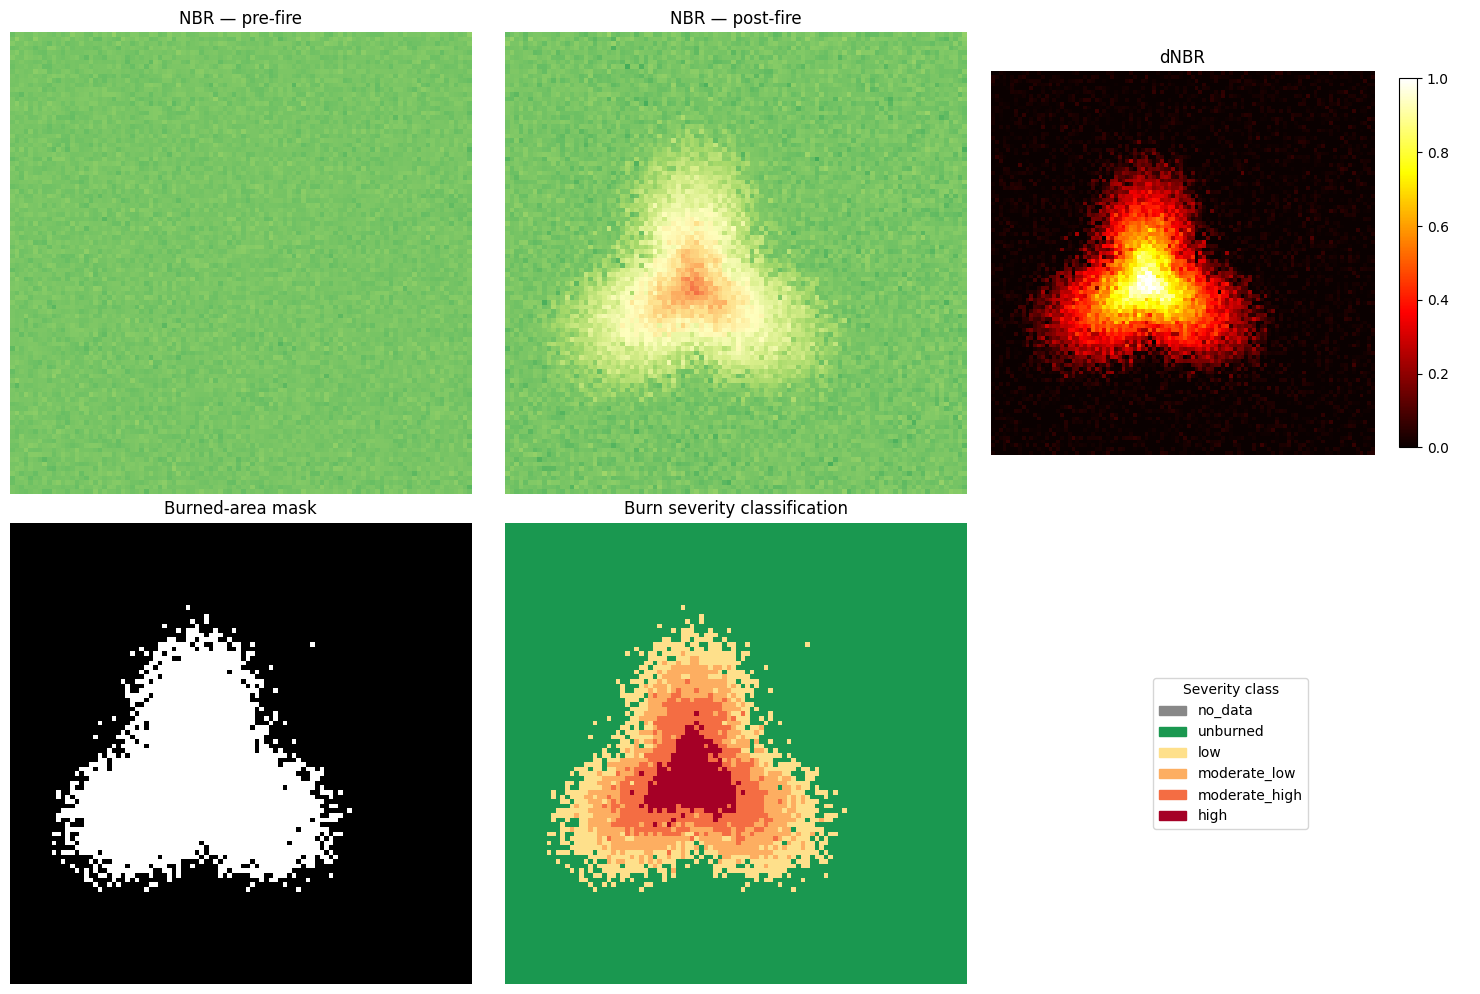

In [4]:
severity_colors = {
    BurnSeverity.NO_DATA: "#888888",
    BurnSeverity.UNBURNED: "#1a9850",
    BurnSeverity.LOW: "#fee08b",
    BurnSeverity.MODERATE_LOW: "#fdae61",
    BurnSeverity.MODERATE_HIGH: "#f46d43",
    BurnSeverity.HIGH: "#a50026",
}
severity_order = list(severity_colors.keys())
severity_index = np.vectorize(lambda s: severity_order.index(s))(result.severity_labels)
cmap = ListedColormap(list(severity_colors.values()))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(nbr_pre, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0, 0].set_title("NBR — pre-fire")
axes[0, 0].axis("off")

axes[0, 1].imshow(nbr_post, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0, 1].set_title("NBR — post-fire")
axes[0, 1].axis("off")

im2 = axes[0, 2].imshow(dnbr, cmap="hot", vmin=0, vmax=1.0)
axes[0, 2].set_title("dNBR")
axes[0, 2].axis("off")
fig.colorbar(im2, ax=axes[0, 2], shrink=0.8)

axes[1, 0].imshow(result.burned_mask, cmap="gray")
axes[1, 0].set_title("Burned-area mask")
axes[1, 0].axis("off")

im4 = axes[1, 1].imshow(severity_index, cmap=cmap, vmin=0, vmax=len(severity_order) - 1)
axes[1, 1].set_title("Burn severity classification")
axes[1, 1].axis("off")

axes[1, 2].axis("off")
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color) for color in severity_colors.values()
]
axes[1, 2].legend(
    legend_patches, [s.value for s in severity_order], loc="center", title="Severity class"
)

plt.tight_layout()
plt.show()


## 4. Affected-area statistics

This is where a pixel classification becomes an actual, reportable number —
hectares affected, using the scene's known pixel resolution.

**Important:** this is a synthetic scene, so these hectare figures describe
this demo scene only — they are not a claim about any real wildfire.

In [5]:
stats = compute_area_stats(result.burned_mask, pixel_resolution_m=PIXEL_RESOLUTION_M)

print(f"Total scene area:     {stats.total_pixels} pixels")
print(f"Burned pixels:        {stats.affected_pixels}")
print(f"Burned area:          {stats.affected_area_hectares:.2f} hectares "
      f"({stats.affected_area_km2:.4f} km^2)")
print(f"Percentage of scene:  {stats.affected_percentage:.1f}%")
print()
print(f"Evidence level: {result.evidence_level.value} "
      f"({result.evidence_level.display_phrase()})")


Total scene area:     10000 pixels
Burned pixels:        1983
Burned area:          19.83 hectares (0.1983 km^2)
Percentage of scene:  19.8%

Evidence level: detected (Detected:)


## 5. Sensitivity to threshold choice

Since burn-severity thresholds are methodology-dependent (see the module
docstring in `src/detection/wildfire.py`), it's worth showing how much the
reported affected area changes with a different, equally defensible
threshold choice — this is exactly why GeoWatch always reports which
thresholds were used alongside any result.

In [6]:
stricter_thresholds = SeverityThresholds(
    unburned_max=0.05, low_max=0.20, moderate_low_max=0.35, moderate_high_max=0.55
)
result_strict = detect_wildfire(dnbr, burn_threshold=0.05, thresholds=stricter_thresholds)
stats_strict = compute_area_stats(result_strict.burned_mask, pixel_resolution_m=PIXEL_RESOLUTION_M)

print(f"Default thresholds  -> burned area: {stats.affected_area_hectares:.2f} ha "
      f"({stats.affected_percentage:.1f}% of scene)")
print(f"Stricter thresholds -> burned area: {stats_strict.affected_area_hectares:.2f} ha "
      f"({stats_strict.affected_percentage:.1f}% of scene)")


Default thresholds  -> burned area: 19.83 ha (19.8% of scene)
Stricter thresholds -> burned area: 23.94 ha (23.9% of scene)


## Next: Milestone 3

This notebook validates the wildfire-detection pipeline end-to-end on a
synthetic scene with known ground truth. Milestone 3 connects real data:
NASA FIRMS active-fire ingestion behind the `SatelliteDataProvider`
abstraction, a PostGIS-backed event store, and an interactive map of live
fire observations.